In [4]:
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [5]:
data = pd.read_csv(r'C:\Users\HP\Desktop\Fund_Data_Analysis\titanic\Titanic-Dataset.csv')
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# Entendimiento de negocio

Objetivo de negocio: ¿Es posible identificar cuales fueron los factores más relevantes para que alguien haya sobrevivido al accidente del Titanic?


Objetivo analítico: Crear un modelo de clasificación a partir de los datos de las personas que estuvieron en el Titanic.

# Entendimiento de los datos

Notebook de exploración de datos.

# Preparación de datos

Para este caso:

- Eliminar columnas irrelevantes.
- Imputación de datos nulos.
- Transformación de variables categóricas.
- Seperación de datos de entrenamiento y pruebas.
- Escalar datos.

In [8]:
# variables que no son relevantes
# 'PassengerId', 'Name', 'Ticket': valores únicos
# 'Cabin': muchos nulos
data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [9]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [10]:
data.dtypes

Survived      int64
Pclass        int64
Sex             str
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked        str
dtype: object

In [11]:
data.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [12]:
imputer_median = SimpleImputer(strategy='median')
imputer_mode = SimpleImputer(strategy='most_frequent')

In [38]:
imputer_median.fit(data[['Age']])
imputer_mode.fit(data[['Embarked']])

data['Age'] = imputer_median.transform(data[['Age']])
data['Embarked'] = imputer_mode.transform(data[['Embarked']]).flatten()

In [39]:
ordinal_encoder = OrdinalEncoder()
onehot_encoder_embarked = OneHotEncoder(drop='first', sparse_output=False)
onehot_encoder_pclass = OneHotEncoder(drop='first', sparse_output=False)

ordinal_encoder.fit(data[['Sex']])
onehot_encoder_embarked.fit(data[['Embarked']])
onehot_encoder_pclass.fit(data[['Pclass']])

data['Sex'] = ordinal_encoder.transform(data[['Sex']])
data[onehot_encoder_embarked.get_feature_names_out()] = onehot_encoder_embarked.transform(data[['Embarked']])
data[onehot_encoder_pclass.get_feature_names_out()] = onehot_encoder_pclass.transform(data[['Pclass']])

In [54]:
ordinal_encoder.categories_

[array(['female', 'male'], dtype=object)]

In [40]:
data.drop(['Embarked', 'Pclass'], axis=1, inplace=True)

In [22]:
data.head()

,Survived,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,0,1.0,22.0,1,0,7.2500,0.0,1.0,0.0,1.0
1,1,0.0,38.0,1,0,71.2833,0.0,0.0,0.0,0.0
2,1,0.0,26.0,0,0,7.9250,0.0,1.0,0.0,1.0
3,1,0.0,35.0,1,0,53.1000,0.0,1.0,0.0,0.0
4,0,1.0,35.0,0,0,8.0500,0.0,1.0,0.0,1.0


In [57]:
data.mean()

,0
Survived,0.383838
Sex,0.647587
Age,29.361582
SibSp,0.523008
Parch,0.381594
Fare,32.204208
Embarked_Q,0.086420
Embarked_S,0.725028
Pclass_2,0.206510
Pclass_3,0.551066


X: datos de entrada (input)

y: datos de salida (output)

In [41]:
X = data.drop('Survived', axis=1)
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
891*0.8

712.8000000000001

In [26]:
X_train.shape, X_test.shape, data.shape

((712, 9), (179, 9), (891, 10))

In [42]:
scaler = StandardScaler() # RESTA A LOS DATOS LA MEDIA Y LUEGO DIVIDE SOBRE LA DESVIACIÓN ESTANDAR
# casi todos los datos van a estar entre -3 y 3 y una propiedad que se va a cumplir de manera obligatoria es que la media será 0 y la std será 1
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Modelación

- Simulación con diferentes modelos.
- Búsqueda y selección de hyper parámetros.

# Evaluación
- ¿Qué tan bien lo hizo cada modelo?
- Definición de mejor modelo.
- Variables de mayor importancia.

Positivo: sobrevivir
Negativo: fallecer

In [49]:
data.head()

,Survived,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,0,1.0,22.0,1,0,7.2500,0.0,1.0,0.0,1.0
1,1,0.0,38.0,1,0,71.2833,0.0,0.0,0.0,0.0
2,1,0.0,26.0,0,0,7.9250,0.0,1.0,0.0,1.0
3,1,0.0,35.0,1,0,53.1000,0.0,1.0,0.0,0.0
4,0,1.0,35.0,0,0,8.0500,0.0,1.0,0.0,1.0



--- Logistic Regression ---
Best Logistic Regression Model: LogisticRegression(C=0.1, max_iter=1000, random_state=42, solver='liblinear')
Training Accuracy (Logistic Regression): 0.8090
Test Accuracy (Logistic Regression): 0.7933


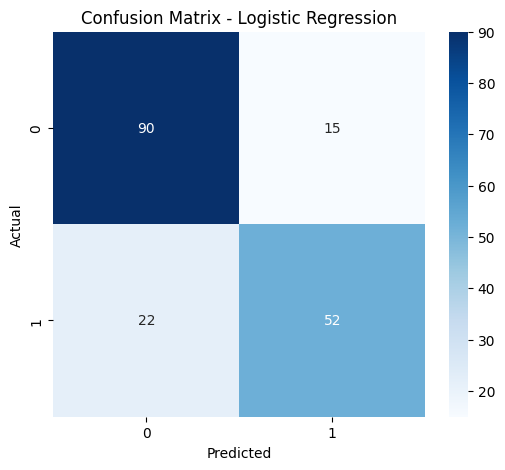


--- Feature Importance (Logistic Regression Coefficients) ---
      Feature  Coefficient
4        Fare     0.226244
5  Embarked_Q    -0.040882
3       Parch    -0.087594
7    Pclass_2    -0.101764
6  Embarked_S    -0.201321
2       SibSp    -0.281612
1         Age    -0.296824
8    Pclass_3    -0.685735
0         Sex    -1.139538

--- SHAP Values (Logistic Regression) ---

Waterfall Plot for a single instance (first in test set):


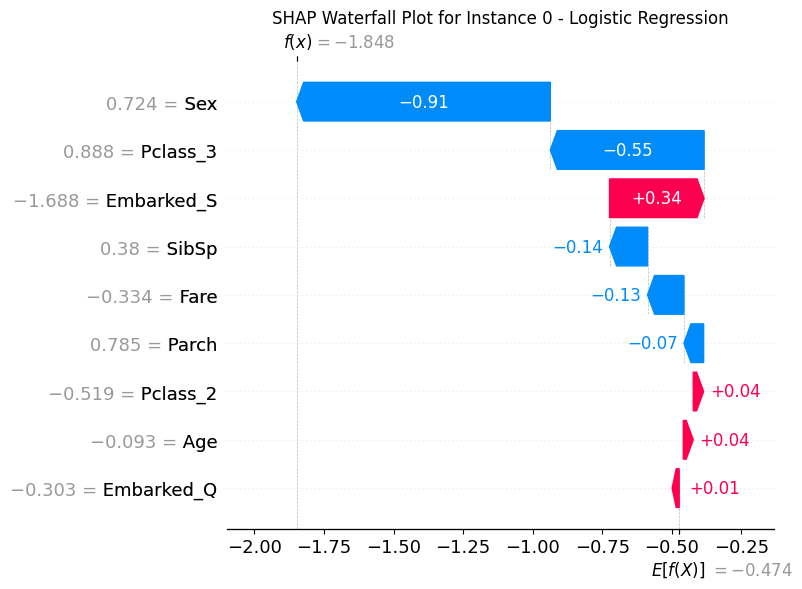

In [43]:
print("\n--- Logistic Regression ---")
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
param_grid_log_reg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

grid_search_log_reg = GridSearchCV(log_reg_model, param_grid_log_reg, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_log_reg.fit(X_train, y_train)

best_log_reg = grid_search_log_reg.best_estimator_
print(f"Best Logistic Regression Model: {best_log_reg}")

y_train_pred_log_reg = best_log_reg.predict(X_train)
y_test_pred_log_reg = best_log_reg.predict(X_test)

print(f"Training Accuracy (Logistic Regression): {accuracy_score(y_train, y_train_pred_log_reg):.4f}")
print(f"Test Accuracy (Logistic Regression): {accuracy_score(y_test, y_test_pred_log_reg):.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred_log_reg), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\n--- Feature Importance (Logistic Regression Coefficients) ---")
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)
print(feature_importance)

print("\n--- SHAP Values (Logistic Regression) ---")

explainer = shap.Explainer(best_log_reg, X_train, feature_names=X.columns)

shap_values = explainer(X_test)

print("\nWaterfall Plot for a single instance (first in test set):")
shap.plots.waterfall(shap_values[0], max_display=10, show=False)
plt.title('SHAP Waterfall Plot for Instance 0 - Logistic Regression')
plt.tight_layout()
plt.show()


Waterfall Plot for a single instance (first in test set):


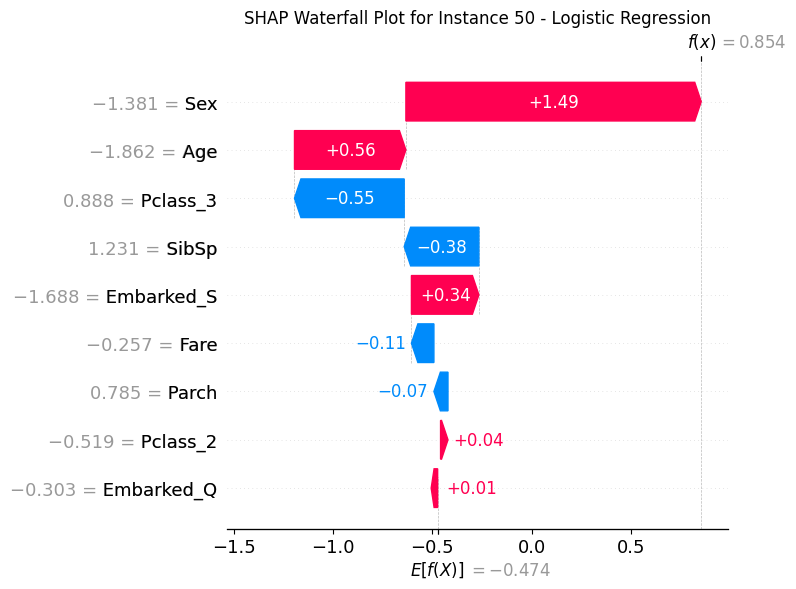

In [56]:
print("\nWaterfall Plot for a single instance (first in test set):")
shap.plots.waterfall(shap_values[50], max_display=10, show=False)
plt.title('SHAP Waterfall Plot for Instance 50 - Logistic Regression')
plt.tight_layout()
plt.show()


--- Decision Tree ---
Best Decision Tree Model: DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=4,
                       random_state=42)
Training Accuracy (Decision Tree): 0.8722
Test Accuracy (Decision Tree): 0.8324


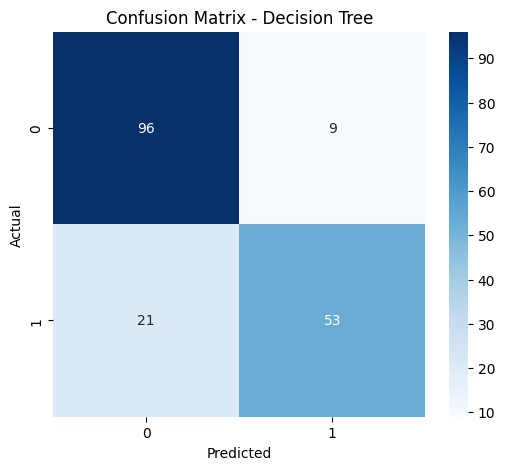


--- Feature Importance (Decision Tree) ---
      Feature  Importance
0         Sex    0.369454
4        Fare    0.248292
8    Pclass_3    0.150586
1         Age    0.141811
2       SibSp    0.058603
6  Embarked_S    0.015232
7    Pclass_2    0.009805
5  Embarked_Q    0.006062
3       Parch    0.000156

--- SHAP Values (Decision Tree) --

Waterfall Plot for a single instance (first in test set):


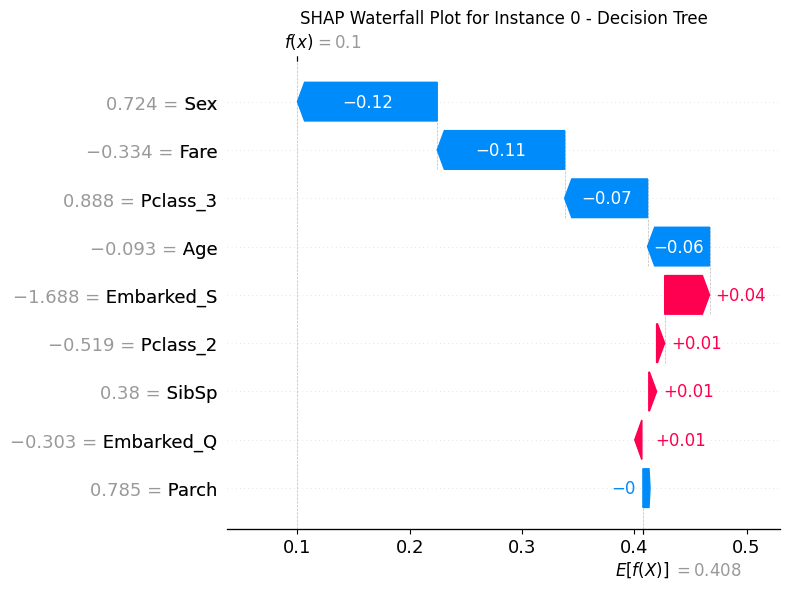

In [44]:
print("\n--- Decision Tree ---")
decision_tree_model = DecisionTreeClassifier(random_state=42)
param_grid_tree = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search_tree = GridSearchCV(decision_tree_model, param_grid_tree, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_tree.fit(X_train, y_train)

best_tree = grid_search_tree.best_estimator_
print(f"Best Decision Tree Model: {best_tree}")

y_train_pred_tree = best_tree.predict(X_train)
y_test_pred_tree = best_tree.predict(X_test)

print(f"Training Accuracy (Decision Tree): {accuracy_score(y_train, y_train_pred_tree):.4f}")
print(f"Test Accuracy (Decision Tree): {accuracy_score(y_test, y_test_pred_tree):.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred_tree), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\n--- Feature Importance (Decision Tree) ---")
feature_importance_tree = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_tree.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(feature_importance_tree)

print("\n--- SHAP Values (Decision Tree) --")

explainer_tree = shap.TreeExplainer(best_tree, X_train, feature_names=X.columns, model_output='probability')

shap_values_tree = explainer_tree(X_test)

print("\nWaterfall Plot for a single instance (first in test set):")
shap.plots.waterfall(shap_values_tree[0, :, 1], max_display=10, show=False)
plt.title('SHAP Waterfall Plot for Instance 0 - Decision Tree')
plt.tight_layout()
plt.show()

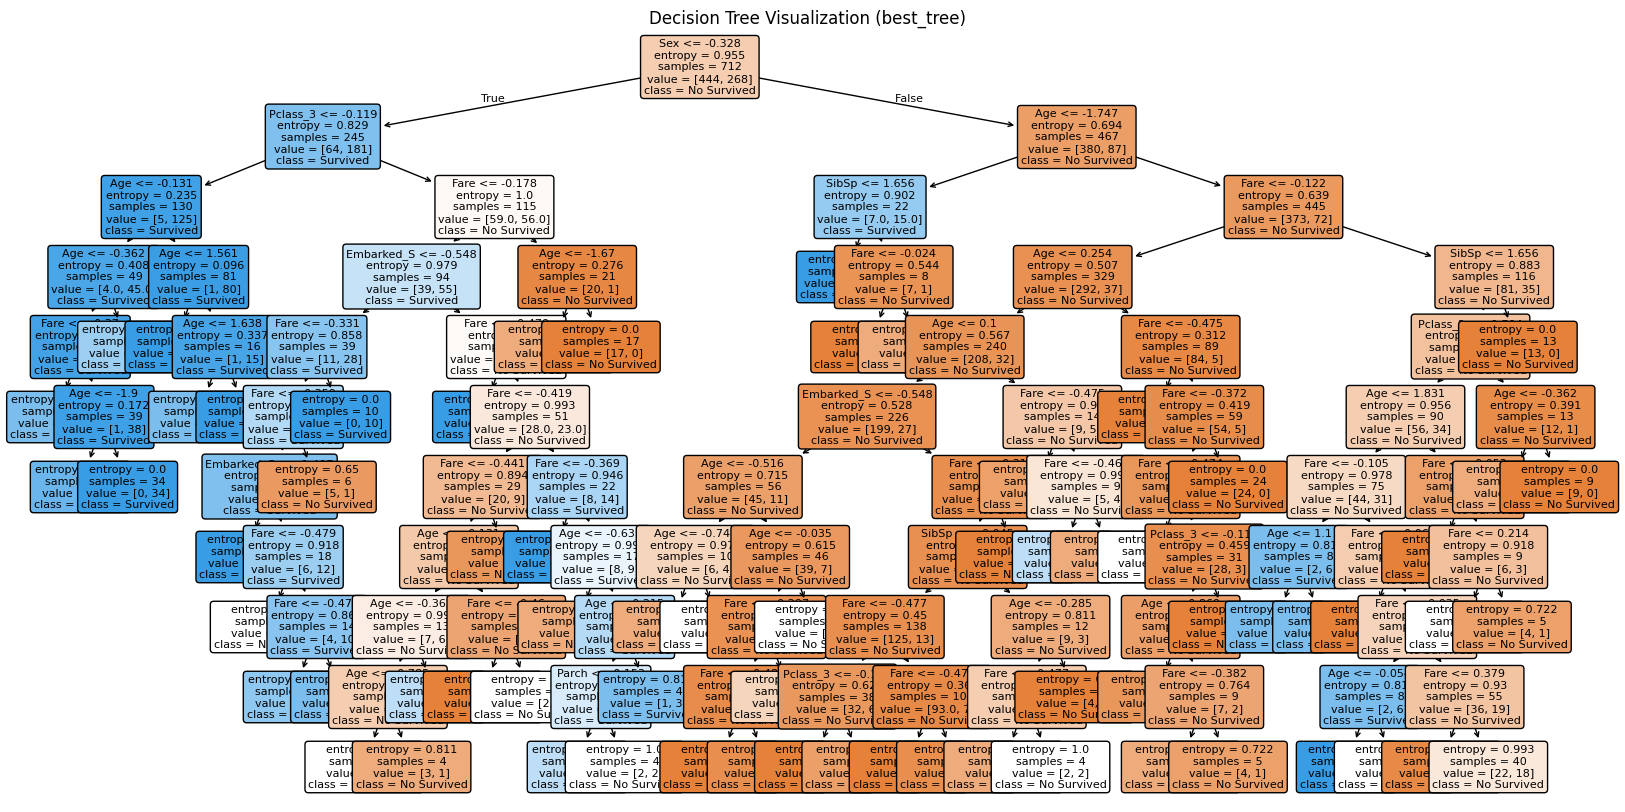

In [47]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(best_tree,
          feature_names=X.columns.tolist(),
          class_names=['No Survived', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title('Decision Tree Visualization (best_tree)')
plt.show()


--- Random Forest ---
Best Random Forest Model: RandomForestClassifier(max_depth=5, min_samples_split=10, n_estimators=50,
                       random_state=42)
Training Accuracy (Random Forest): 0.8469
Test Accuracy (Random Forest): 0.8212


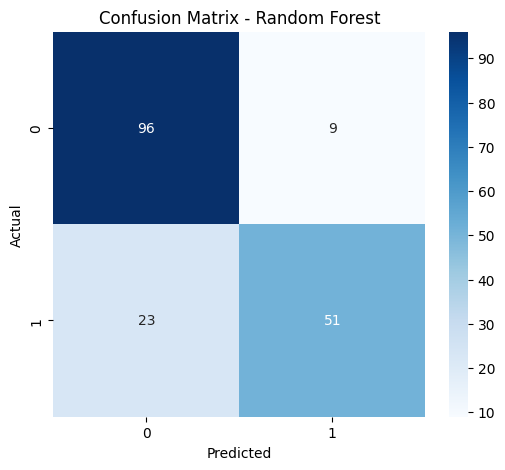


--- Feature Importance (Random Forest) ---
      Feature  Importance
0         Sex    0.484015
4        Fare    0.154972
8    Pclass_3    0.131569
1         Age    0.099186
2       SibSp    0.051660
6  Embarked_S    0.026599
7    Pclass_2    0.020729
3       Parch    0.020551
5  Embarked_Q    0.010718

--- SHAP Values (Random Forest) --

Waterfall Plot for a single instance (first in test set):


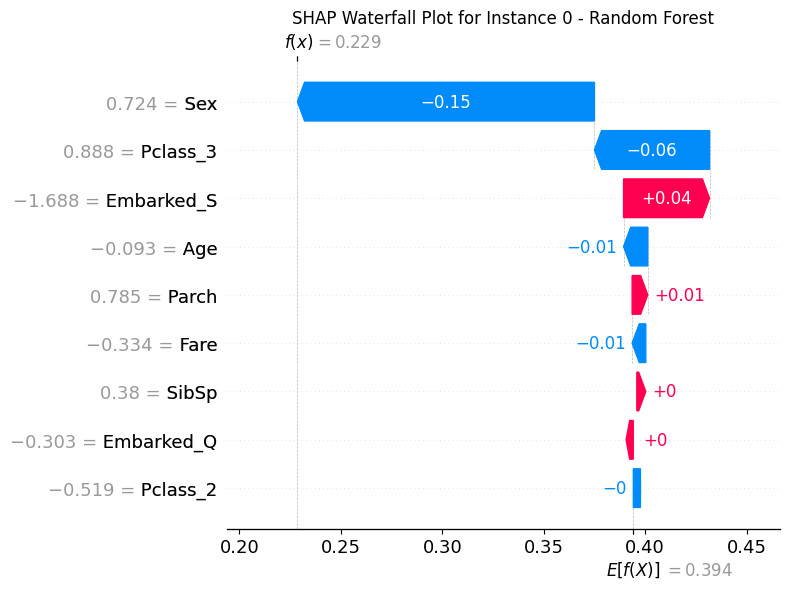

In [45]:
print("\n--- Random Forest ---")
random_forest_model = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf = GridSearchCV(random_forest_model, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

best_rf = grid_search_rf.best_estimator_
print(f"Best Random Forest Model: {best_rf}")

y_train_pred_rf = best_rf.predict(X_train)
y_test_pred_rf = best_rf.predict(X_test)

print(f"Training Accuracy (Random Forest): {accuracy_score(y_train, y_train_pred_rf):.4f}")
print(f"Test Accuracy (Random Forest): {accuracy_score(y_test, y_test_pred_rf):.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\n--- Feature Importance (Random Forest) ---")
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(feature_importance_rf)

print("\n--- SHAP Values (Random Forest) --")

explainer_rf = shap.TreeExplainer(best_rf, X_train, feature_names=X.columns, model_output='probability')

shap_values_rf = explainer_rf(X_test)

print("\nWaterfall Plot for a single instance (first in test set):")
shap.plots.waterfall(shap_values_rf[0, :, 1], max_display=10, show=False)
plt.title('SHAP Waterfall Plot for Instance 0 - Random Forest')
plt.tight_layout()
plt.show()

## ¿Cúal es el mejor modelo?

POsitivo: no está enferma
Negativo: está enferma